# **DCIS301 Curso disciplinar avanzado. Procesamiento de señales biomédicas**
## Profesor: David Ortiz
=========================================

---

**Recuerde los lineamientos indicados en la Guía detallada del curso presentada el primer día de clase. Algunos a resaltar:**

- Los quices se han eliminado, lo que implica que la nota del informe escrito será la nota final del informe.
- Respetar el número máximo de páginas estipuladas. Se descontarán 2 décimas por página adicional.
- El informe debe ser digitado en un editor de texto (Word, $\LaTeX$, Documentos de Google) y enviado en formato PDF. No se aceptarán informes escritos a mano.
- **Solo está permitido el uso de ChatGPT, y deberán incluir en el informe el link de la conversación (Chat) con el programa.**
- **Los códigos empleados deberán ser incluidos al final del informe escrito, y estos no sumarán al máximo número de páginas establecido.**
- Antes de la fecha y hora límite, el informe en formato PDF debe ser subido al *Aula Virtual*, en la pestaña correspondiente. Recuerden que la originalidad del informe será evaluada con la herramienta Turniting, y esto considera el correcto uso de ChatGPT.
- Se espera que las respuestas sean explícitas, detalladas y matemáticamente soportadas. Es fundamental utilizar la teoría vista en clase para sustentar los argumentos, incluyendo fórmulas, ecuaciones, transformaciones y cualquier otro recurso necesario para respaldar el razonamiento. La precisión y solidez de la fundamentación será un criterio clave en la evaluación.

---

*Se otorgará una bonificación de 0.3 puntos si el informe está redactado en inglés, y una bonificación adicional de 0.3 puntos si se utiliza* $\LaTeX$ *para su digitación. Para verificar este último criterio, se debe adjuntar el archivo* `.tex` *del informe en el mensaje de entrega.*

Funciones auxiliares para el desarrollo de la tarea 3 y 4:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import (
    butter, find_peaks, spectrogram, 
    get_window, filtfilt, freqz
    )
from scipy.stats import entropy, kurtosis, skew

import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def graficar_fourier(signal, fs, ax=None, only_magnitude=True, logarithmic=True):
    """
    Calcula y grafica la FFT. Si ax es None, crea figura nueva con magnitud y fase.
    Si ax es un eje matplotlib, grafica solo la magnitud en ese eje.
    
    Args:
        signal (np.ndarray): Señal de entrada.
        fs (float): Frecuencia de muestreo (Hz).
        ax (matplotlib.axes.Axes): Eje donde graficar la magnitud (opcional).
        only_magnitude (bool): Si True, solo grafica la magnitud.
    """
    Nsample = len(signal)
    yf = fft(signal)[:Nsample // 2]
    xf = fftfreq(Nsample, d=1/fs)[:Nsample // 2]  # Tomar solo frecuencias positivas
    
    magnitude = 2 * np.abs(yf) / Nsample
    if logarithmic:
        # Convertir a escala logarítmica
        magnitude = 10 * np.log10(magnitude + 1e-10)
    phase = np.angle(yf)

    # Eliminar componentes cercanas a cero en la fase
    threshold = 1e-6  # Umbral para eliminar componentes pequeñas
    phase[np.abs(magnitude) < threshold] = 0  # Asignar fase cero donde la magnitud es pequeña

    if ax is None:
        # Gráfica normal: magnitud y fase en figura nueva
        plt.figure(figsize=(8, 6))
        # Magnitud
        ax1 = plt.subplot(2, 1, 1)
        ax1.plot(xf, magnitude, color='b')
        ax1.set_xlabel(r"Frecuencia [Hz]", size=16)
        ax1.set_ylabel(r"$|X(f)|$", size=16)
        ax1.set_title(f'Espectro de Fourier de la señal', size=16)
        ax1.grid(True)
        # Fase (opcional)
        if not only_magnitude:
            ax2 = plt.subplot(2, 1, 2)
            ax2.plot(xf, phase, color='b')
            ax2.set_xlabel("Frecuencia [Hz]", size=16)
            ax2.set_ylabel(r"$\phi(f)$", size=16)
            ax2.set_title("Fase", size=16)
            ax2.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        # Graficar solo magnitud en axes dado
        ax.plot(xf, magnitude, color='b')
        ax.set_xlabel(r"Frecuencia [Hz]", size=14)
        ax.set_ylabel(r"$|X(f)|$", size=14)
        ax.set_title(f'FFT Magnitud', size=14)
        ax.grid(True)


def plot_spectrogram(signal, sample_rate, overlapping = 0.5, window_type='hann', window_size=256, ax = None):
    """
    Genera y grafica el espectrograma de una señal.

    Parámetros:
    - signal: la señal de audio
    - window_type: el tipo de ventana a usar (string, por ejemplo 'hann', 'hamming', etc.)
    - window_size: tamaño de la ventana (entero)
    - overlapping: porcentaje de solapamiento (valor entre 0 y 1)
    - fs: frecuencia de muestreo de la señal
    """
    # Crear la ventana
    window = get_window(window_type, window_size)

    # Calcular el paso de la ventana en función del solapamiento
    noverlap = int(overlapping * window_size)

    # Calcular el espectrograma usando scipy.signal.spectrogram
    f, t, Sxx = spectrogram(signal, fs=sample_rate, window=window,
                            nperseg=window_size, noverlap=noverlap)

    if ax is None:
        # Graficar el espectrograma
        plt.figure(figsize=(5, 3))
        plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
        plt.title('Espectrograma')
        plt.xlabel('Tiempo [s]')
        plt.colorbar(label='Amplitud [dB]')
        plt.show()
    else:
        # Graficar en el eje dado
        ax.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
        ax.set_title('Espectrograma')
        ax.set_ylabel('Frecuencia [Hz]')
        ax.set_xlabel('Tiempo [s]')
        ax.colorbar(label='Amplitud [dB]')
        ax.grid(True)
    
def normalize_zscore(signal):
    """
    Estandarización Z-score: Media 0 y Desviación Estándar 1.
    Ideal para preservar la varianza y mitigar el efecto de valores atípicos.
    """
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    
    if std_val == 0:
        return signal - mean_val
        
    return (signal - mean_val) / std_val

def normalize_minmax_symmetric(signal):
    """
    Escalado Min-Max al rango [-1, 1].
    Útil cuando los algoritmos requieren límites estrictos, 
    pero muy sensible a valores atípicos.
    """
    min_val = np.min(signal)
    max_val = np.max(signal)
    
    if max_val == min_val:
        return np.zeros_like(signal)
        
    # Primero se escala a [0, 1] y luego se transforma a [-1, 1]
    norm_01 = (signal - min_val) / (max_val - min_val)
    return 2 * norm_01 - 1


def compute_stat_metrics(signal, sample_rate, window_size=128, overlap=0.0, window_type='boxcar', hist_bins=10):
    """
    Calcula métricas estadísticas sobre ventanas solapadas de una señal 1D.
    
    Args:
        signal (ndarray): Señal de entrada.
        sample_rate (float): Frecuencia de muestreo (Hz).
        window_size (int): Tamaño de la ventana en muestras.
        overlap (float): Fracción de solapamiento [0,1).
        window_type (str): Tipo de ventana (e.g., 'boxcar', 'hann').
        hist_bins (int): Número de bins para el cálculo de entropía.
    
    Returns:
        dict: Contiene 'times' y un diccionario con listas de métricas.
    """
    t = np.linspace(0, len(signal)/sample_rate, len(signal), endpoint=False)
    step = int(window_size * (1 - overlap))
    win = get_window(window_type, window_size)
    
    times = []
    metrics = {k: [] for k in ['mean','variance','median','max','min','range','shannon_entropy','kurtosis','skewness']}
    
    for start in range(0, len(signal) - window_size + 1, step):
        segment = signal[start:start + window_size] * win
        times.append(t[start + window_size - 1])
        
        metrics['mean'].append(np.mean(segment))
        metrics['variance'].append(np.var(segment))
        metrics['median'].append(np.median(segment))
        metrics['max'].append(np.max(segment))
        metrics['min'].append(np.min(segment))
        metrics['range'].append(np.max(segment) - np.min(segment))
        
        hist, _ = np.histogram(segment, bins=hist_bins, density=True)
        metrics['shannon_entropy'].append(entropy(hist + 1e-12, base=2))
        metrics['kurtosis'].append(kurtosis(segment))
        metrics['skewness'].append(skew(segment))
    
    return times, metrics

def compute_dynamic_metrics(signal, sample_rate, window_size=128, overlap=0.5, window_type='boxcar'):
    """
    Calcula métricas dinámicas sobre ventanas solapadas de una señal 1D.
    
    Args:
        signal (ndarray): Señal de entrada.
        sample_rate (float): Frecuencia de muestreo (Hz).
        window_size (int): Tamaño de ventana en muestras.
        overlap (float): Fracción de solapamiento [0,1).
        window_type (str): Tipo de ventana (e.g., 'boxcar', 'hann').
    
    Returns:
        dict: Contiene 'times' y un diccionario con listas de métricas dinámicas.
    """
    t = np.linspace(0, len(signal)/sample_rate, len(signal), endpoint=False)
    step = int(window_size * (1 - overlap))
    win = get_window(window_type, window_size)
    
    times = []
    metrics_dyn = {k: [] for k in ['zcr','zcr_var','slope','velocity','acceleration','peak_count','energy','power']}
    
    for start in range(0, len(signal) - window_size + 1, step):
        segment = signal[start:start + window_size] * win
        times.append(t[start])
        
        # Cruces por cero
        zero_crossings = np.where(np.diff(np.sign(segment)) != 0)[0]
        metrics_dyn['zcr'].append(len(zero_crossings))
        metrics_dyn['zcr_var'].append(np.var(np.diff(zero_crossings)) if len(zero_crossings) > 1 else 0)
        
        # Derivadas
        diff1 = np.diff(segment)
        diff2 = np.diff(diff1)
        metrics_dyn['slope'].append(np.mean(diff1))
        metrics_dyn['velocity'].append(np.mean(np.abs(diff1)))
        metrics_dyn['acceleration'].append(np.mean(np.abs(diff2)))
        
        # Picos
        peaks, _ = find_peaks(segment)
        metrics_dyn['peak_count'].append(len(peaks))
        
        # Energía y potencia
        energy = np.sum(segment**2)
        metrics_dyn['energy'].append(energy)
        metrics_dyn['power'].append(energy / window_size)
    
    return times, metrics_dyn


def tsne_simple(señal1, señal2, fs=360, window_type = 'boxcar', window_size=128, overlap=0.5, perplexity=30, plot=True):
    """
    t-SNE simple para dos señales (reposo y sueño) usando métricas por ventanas.
    Requiere tener definidas: compute_windowed_metrics y compute_dynamic_metrics.
    """
    # Reposo
    m_r = {**compute_stat_metrics(señal1, fs,  window_size, overlap, window_type)[1],
           **compute_dynamic_metrics(señal1, fs,  window_size, overlap, window_type)[1]}
    df_r = pd.DataFrame(m_r); df_r['cond'] = 'señal1'
    # Sueño
    m_s = {**compute_stat_metrics(señal2, fs, window_size, overlap, window_type)[1],
           **compute_dynamic_metrics(señal2, fs, window_size, overlap, window_type)[1]}
    df_s = pd.DataFrame(m_s); df_s['cond'] = 'señal2'

    df = pd.concat([df_r, df_s], ignore_index=True)
    labels = df['cond'].to_numpy()
    X = df.drop(columns=['cond']).to_numpy()

    X_scaled = StandardScaler().fit_transform(X)
    X_tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(X_scaled)

    if plot:
        plt.figure(figsize=(5.2, 4.5))
        for c, name in [('señal1', 'Señal 1'), ('señal2', 'Señal 2')]:
            idx = labels == c
            plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=32, alpha=0.8, edgecolor='k', label=name)
        plt.title("t-SNE de métricas por ventana — Señal 1 vs. Señal 2")
        plt.xlabel("Comp. 1"); plt.ylabel("Comp. 2"); plt.legend(); plt.grid(True, ls='--', alpha=0.3)
        plt.tight_layout(); plt.show()

    return {"embedding": X_tsne, "labels": labels, "features": df}


## **Apnea-ECG Database**

DOI (version 1.0.0):
https://doi.org/10.13026/C23W2R

=== Group A — Apnea (pathological) ===
  a01: OK
  a02: OK
  a03: OK
  a04: OK
  a05: OK
  a06: OK
  a07: OK
  a08: OK
  a09: OK
  a10: OK
  a11: OK
  a12: OK
  a13: OK
  a14: OK
  a15: OK
  a16: OK
  a17: OK
  a18: OK
  a19: OK
  a20: OK

=== Group C — Control (no apnea) ===
  c01: OK
  c02: OK
  c03: OK
  c04: OK
  c05: OK
  c06: OK
  c07: OK
  c08: OK
  c09: OK
  c10: OK

=== Resumen de registros seleccionados ===
  a01 (Apnea): fs=100 Hz | muestras=2957000 | duración=29570s (492.8 min) | canal=['ECG']
  c01 (Control): fs=100 Hz | muestras=2899000 | duración=28990s (483.2 min) | canal=['ECG']

Segmento seleccionado: muestras 70000–72000  (11.7 – 12.0 min)


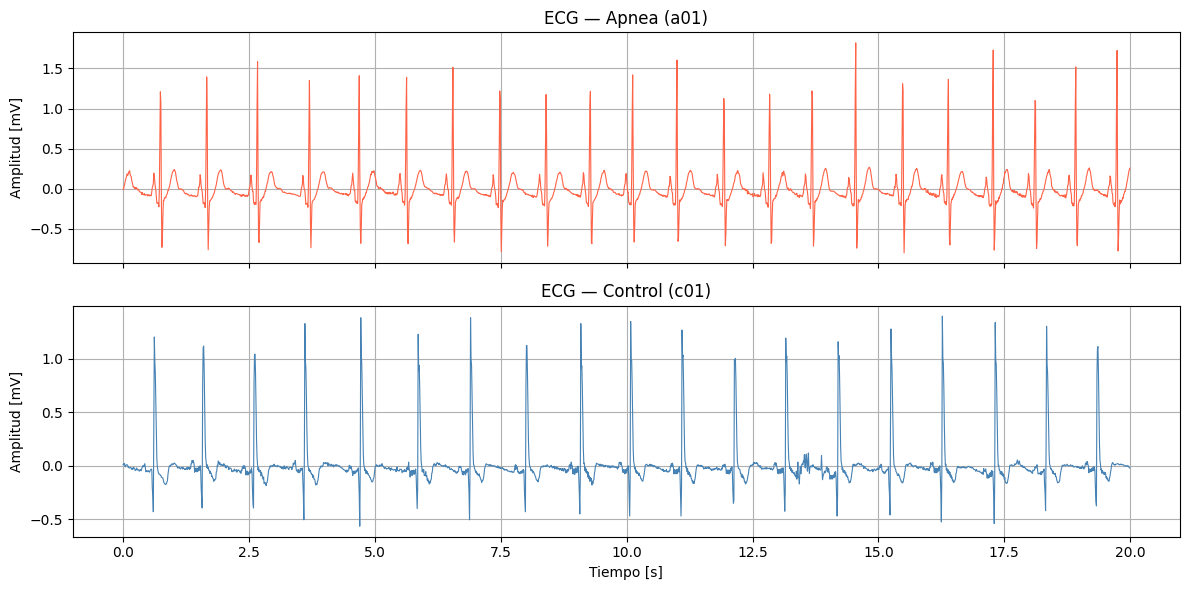

In [8]:
import wfdb
import os

DATA_DIR = 'data'

# --- Verificación del dataset ---
group_a = [f'a{i:02d}' for i in range(1, 21)]
group_c = [f'c{i:02d}' for i in range(1, 11)]

print("=== Group A — Apnea (pathological) ===")
for name in group_a:
    ok = all(os.path.exists(f'{DATA_DIR}/{name}{ext}') for ext in ['.dat', '.hea'])
    print(f"  {name}: {'OK' if ok else 'MISSING'}")

print("\n=== Group C — Control (no apnea) ===")
for name in group_c:
    ok = all(os.path.exists(f'{DATA_DIR}/{name}{ext}') for ext in ['.dat', '.hea'])
    print(f"  {name}: {'OK' if ok else 'MISSING'}")

# --- Carga de registros representativos ---
record_apnea   = wfdb.rdrecord(f'{DATA_DIR}/a01')   # patológico
record_control = wfdb.rdrecord(f'{DATA_DIR}/c01')   # control

fs = record_apnea.fs
assert record_apnea.fs == record_control.fs == 100, "fs mismatch!"

print("\n=== Resumen de registros seleccionados ===")
for label, rec in [('a01 (Apnea)', record_apnea), ('c01 (Control)', record_control)]:
    n = rec.sig_len
    print(f"  {label}: fs={rec.fs} Hz | muestras={n} | "
          f"duración={n/rec.fs:.0f}s ({n/rec.fs/60:.1f} min) | canal={rec.sig_name}")

# --- Segmento de ~20 s (2 000 muestras @ 100 Hz) ---
# Se toma desde el minuto 10 (60 000 muestras) para evitar artefactos iniciales
seg_start = 70_000
seg_end   = seg_start + 20 * fs      # 2 000 muestras = 20 s

ecg_apnea   = record_apnea.p_signal[seg_start:seg_end, 0]
ecg_control = record_control.p_signal[seg_start:seg_end, 0]

t = np.arange(len(ecg_apnea)) / fs   # eje de tiempo [s]

print(f"\nSegmento seleccionado: muestras {seg_start}–{seg_end}  "
      f"({seg_start/fs/60:.1f} – {seg_end/fs/60:.1f} min)")

# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, ecg_apnea,   color='tomato',   lw=0.8)
axes[0].set_title('ECG — Apnea (a01)')
axes[0].set_ylabel('Amplitud [mV]')
axes[0].grid(True)

axes[1].plot(t, ecg_control, color='steelblue', lw=0.8)
axes[1].set_title('ECG — Control (c01)')
axes[1].set_ylabel('Amplitud [mV]')
axes[1].set_xlabel('Tiempo [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()